In [1]:
from pathlib import Path

audio_dir = Path('../data/raw/deam/MEMD_audio')
audio_paths = sorted(audio_dir.glob('*.mp3'))

print(f'Found {len(audio_paths)} audio files')

for path in audio_paths[:5]:
    print(path.name)

Found 1802 audio files
10.mp3
1000.mp3
1001.mp3
1002.mp3
1003.mp3


In [2]:
import soundfile as sf

path = audio_paths[0]
info = sf.info(path)

print(path.name)
print(info)

10.mp3
../data/raw/deam/MEMD_audio/10.mp3
samplerate: 44100 Hz
channels: 2
duration: 45.061 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]


In [3]:
info.samplerate

44100

In [4]:
from collections import defaultdict

audio_data = defaultdict(list)

for i, path in enumerate(audio_paths):
    info = sf.info(path)
    audio_data['track_id'].append(int(path.stem))
    audio_data['samplerate'].append(info.samplerate)
    audio_data['channels'].append(info.channels)
    audio_data['duration_sec'].append(info.duration)
    audio_data['frames'].append(info.frames)
    audio_data['format'].append(info.format)
    audio_data['subtype'].append(info.subtype)
    audio_data['size_bytes'].append(path.stat().st_size)

In [5]:
import pandas as pd

audio_df = pd.DataFrame(audio_data)
audio_df.head()

,track_id,samplerate,channels,duration_sec,frames,format,subtype,size_bytes
0,10,44100,2,45.060998,1987190,MP3,MPEG_LAYER_III,620385
1,1000,44100,2,45.060998,1987190,MP3,MPEG_LAYER_III,622927
2,1001,44100,2,45.000023,1984501,MP3,MPEG_LAYER_III,723956
3,1002,44100,2,45.330385,1999070,MP3,MPEG_LAYER_III,723750
4,1003,44100,2,45.330385,1999070,MP3,MPEG_LAYER_III,723750


In [6]:
print(audio_df.shape)
print(audio_df['track_id'].is_unique)
print(audio_df.isna().sum())

audio_df.describe()

(1802, 8)
True
track_id        0
samplerate      0
channels        0
duration_sec    0
frames          0
format          0
subtype         0
size_bytes      0
dtype: int64


,track_id,samplerate,channels,duration_sec,frames,size_bytes
count,1802.000000,1802.000000,1802.000000,1802.000000,1.802000e+03,1.802000e+03
mean,1093.215871,44090.982242,1.992786,51.151757,2.255387e+06,7.660832e+05
std,599.658004,1190.437319,0.084653,38.462281,1.697098e+06,6.264881e+05
min,2.000000,16000.000000,1.000000,44.643039,7.200010e+05,2.736400e+05
25%,569.500000,44100.000000,2.000000,45.000023,1.984501e+06,6.122115e+05
50%,1157.500000,44100.000000,2.000000,45.034875,1.986038e+06,7.239240e+05
75%,1607.750000,44100.000000,2.000000,45.060998,1.987190e+06,7.239560e+05
max,2058.000000,48000.000000,2.000000,628.616485,2.772199e+07,1.003478e+07


In [7]:
for column in ['samplerate', 'channels', 'format', 'subtype']:
    print(f"\n{column}")
    print(audio_df[column].value_counts())


samplerate
samplerate
44100    1778
48000      20
22050       3
16000       1
Name: count, dtype: int64

channels
channels
2    1789
1      13
Name: count, dtype: int64

format
format
MP3    1802
Name: count, dtype: int64

subtype
subtype
MPEG_LAYER_III    1802
Name: count, dtype: int64


<Axes: xlabel='duration_sec', ylabel='Count'>

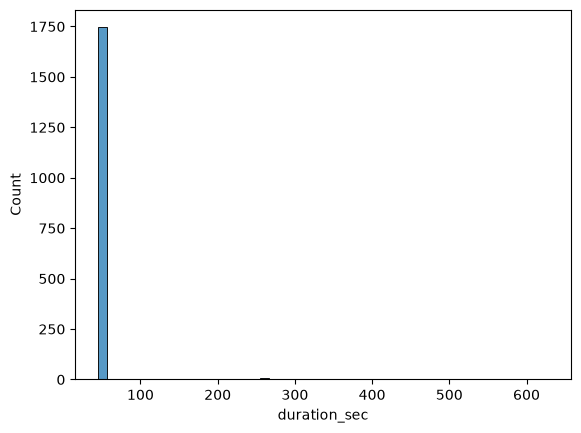

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(audio_df, x='duration_sec', bins=50)

In [9]:
len(audio_df[audio_df.duration_sec > 60])

56

Обнаружена неоднородная структура CSV; обработка метаданных отложена

In [10]:
metadata_dir = Path('../data/raw/deam/metadata')
metadata_paths = metadata_dir.glob('*.csv')

In [11]:
import numpy as np

audio, sample_rate = sf.read(audio_paths[0])
time = np.arange(audio.shape[0]) / sample_rate

Text(0.5, 1.0, '10.mp3')

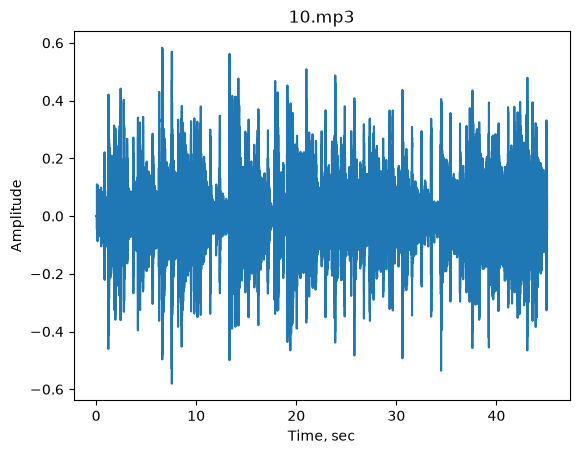

In [12]:
plt.plot(time, audio[:, 0])
plt.xlabel("Time, sec")
plt.ylabel("Amplitude")
plt.title(audio_paths[0].name)

Text(0, 0.5, 'Amplitude')

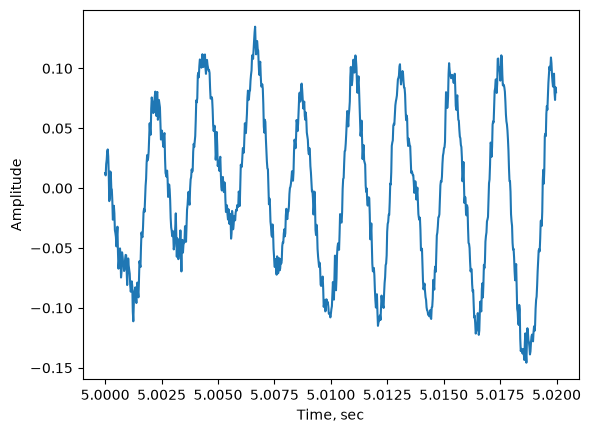

In [13]:
start_sec = 5.0
duration_sec = 0.02

start = int(start_sec * sample_rate)
end = start + int(duration_sec * sample_rate)

plt.plot(time[start:end], audio[start:end, 0])
plt.xlabel("Time, sec")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

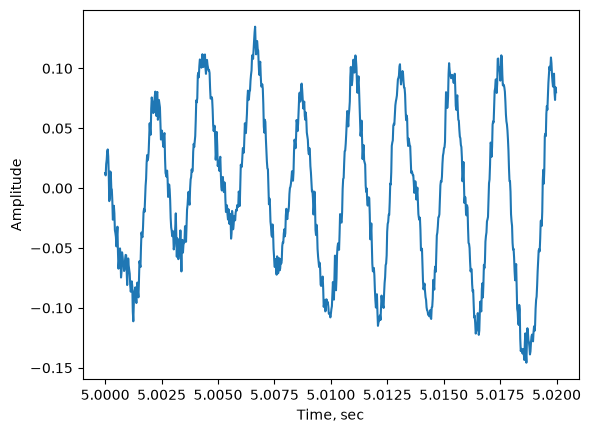

In [14]:
audio_mono = audio.mean(axis=1)
plt.plot(time[start:end], audio_mono[start:end])
plt.xlabel("Time, sec")
plt.ylabel("Amplitude")

In [15]:
start = int(5.0 * sample_rate)
n_fft = 2048

segment = audio_mono[start:start + n_fft]

window = np.hanning(n_fft)
windowed_segment = window * segment

spectrum = np.fft.rfft(windowed_segment)
frequencies = np.fft.rfftfreq(n_fft, d=1 / sample_rate)

(-1102.5, 3000.0)

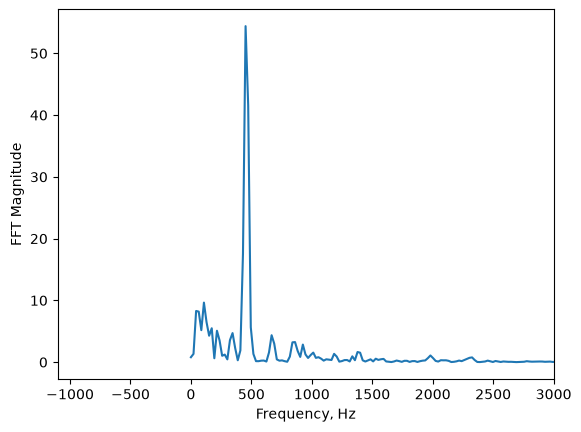

In [16]:
plt.plot(frequencies, np.abs(spectrum))
plt.xlabel('Frequency, Hz')
plt.ylabel('FFT Magnitude')
plt.xlim(right=3000)

In [17]:
signal = audio_mono[:int(5 * sample_rate)]

n_fft = 2048
hop_length = 512
window = np.hanning(n_fft)
frequencies = np.fft.rfftfreq(n_fft, d=1 / sample_rate)

spectra = []

for start in range(0, len(signal) - n_fft + 1, hop_length):

    segment = signal[start:start + n_fft]
    windowed_segment = window * segment

    spectrum = np.fft.rfft(windowed_segment)
    spectra.append(spectrum)

stft = np.stack(spectra, axis=1)
print(stft.shape)

(1025, 427)


In [18]:
magnitude = np.abs(stft)
reference = magnitude.max()

spectrogram_db = 20 * np.log10(
    np.maximum(magnitude / reference, 1e-5)
)

times = (
    np.arange(stft.shape[1]) * hop_length + n_fft / 2
) / sample_rate

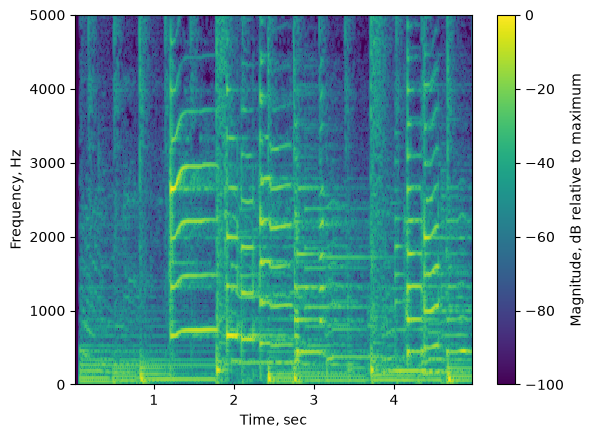

In [19]:
plt.pcolormesh(times, frequencies, spectrogram_db, shading="auto")
plt.ylim(0, 5000)
plt.xlabel("Time, sec")
plt.ylabel("Frequency, Hz")
plt.colorbar(label="Magnitude, dB relative to maximum")

In [20]:
from scipy.ndimage import maximum_filter

local_max = maximum_filter(
    spectrogram_db,
    size=(15, 21),
    mode="nearest",
)

In [21]:
spectrogram_db.shape

(1025, 427)

In [22]:
peak_mask = (spectrogram_db == local_max) & (spectrogram_db > -40)
frequency_indices, time_indices = np.where(peak_mask)

Detected peaks: 232


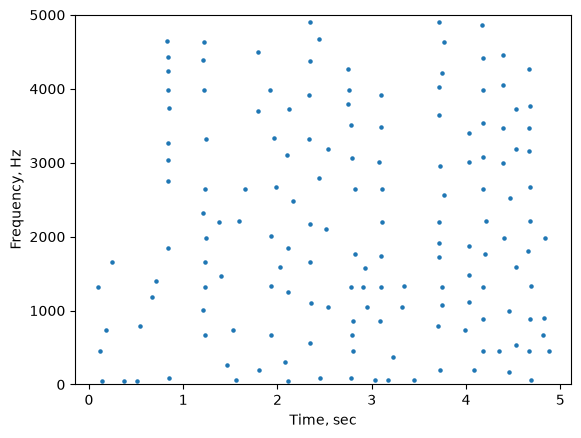

In [23]:
plt.scatter(
    times[time_indices],
    frequencies[frequency_indices],
    s=5,
)
plt.xlabel("Time, sec")
plt.ylabel("Frequency, Hz")
plt.ylim(0, 5000)

print(f"Detected peaks: {len(time_indices)}")

Text(0, 0.5, 'Frequency, Hz')

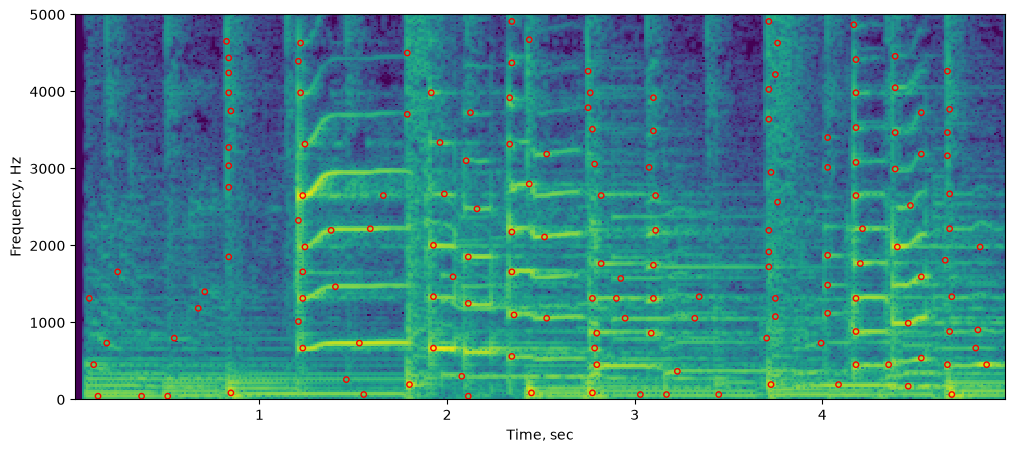

In [24]:
plt.figure(figsize=(12, 5))
plt.pcolormesh(times, frequencies, spectrogram_db, shading="auto")
plt.scatter(
    times[time_indices],
    frequencies[frequency_indices],
    s=15,
    facecolors="none",
    edgecolors="red",
)
plt.ylim(0, 5000)
plt.xlabel("Time, sec")
plt.ylabel("Frequency, Hz")

In [25]:
order = np.argsort(time_indices, kind="stable")

peak_times = time_indices[order]
peak_frequencies = frequency_indices[order]
list(zip(peak_times[:10], peak_frequencies[:10]))

[(np.int64(6), np.int64(61)),
 (np.int64(8), np.int64(21)),
 (np.int64(10), np.int64(2)),
 (np.int64(14), np.int64(34)),
 (np.int64(14), np.int64(331)),
 (np.int64(14), np.int64(412)),
 (np.int64(19), np.int64(77)),
 (np.int64(30), np.int64(2)),
 (np.int64(42), np.int64(2)),
 (np.int64(42), np.int64(331))]